In [1]:
# ============================================================
# STEP 1: Upload & Load Dataset
# ============================================================
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=== Shape ===", df.shape)
print("\n=== First 5 Rows ===")
print(df.head())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Distribution ===")
print(df['species'].value_counts())
print("\n=== Basic Statistics ===")
print(df.describe())

Saving 1) iris.csv to 1) iris.csv
=== Shape === (150, 5)

=== First 5 Rows ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== Data Types ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Target Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== Basic Statistics ===
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000

In [2]:
# ============================================================
# STEP 2: Preprocess the Data
# ============================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_clean = df.copy()

# --- Encode target labels ---
le = LabelEncoder()
df_clean['species_encoded'] = le.fit_transform(df_clean['species'])

print("=== Label Encoding ===")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# --- Features and Target ---
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df_clean[feature_cols]
y = df_clean['species_encoded']

# --- 80/20 Stratified Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Classes          : {list(le.classes_)}")

=== Label Encoding ===
  setosa → 0
  versicolor → 1
  virginica → 2

Training samples : 120
Testing samples  : 30
Classes          : ['setosa', 'versicolor', 'virginica']


In [3]:
# ============================================================
# STEP 3: Train Full Decision Tree (No Pruning)
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# --- Train full tree (no depth limit = prone to overfitting) ---
dt_full = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_full.fit(X_train, y_train)

y_pred_full = dt_full.predict(X_test)

acc_full = accuracy_score(y_test, y_pred_full)
f1_full  = f1_score(y_test, y_pred_full, average='weighted')

print("=" * 50)
print("   FULL TREE (Unpruned) — Evaluation")
print("=" * 50)
print(f"  Tree Depth    : {dt_full.get_depth()}")
print(f"  Leaf Nodes    : {dt_full.get_n_leaves()}")
print(f"  Accuracy      : {acc_full*100:.2f}%")
print(f"  F1-Score      : {f1_full*100:.2f}%")
print("=" * 50)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_full, target_names=le.classes_))

   FULL TREE (Unpruned) — Evaluation
  Tree Depth    : 5
  Leaf Nodes    : 8
  Accuracy      : 93.33%
  F1-Score      : 93.33%

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



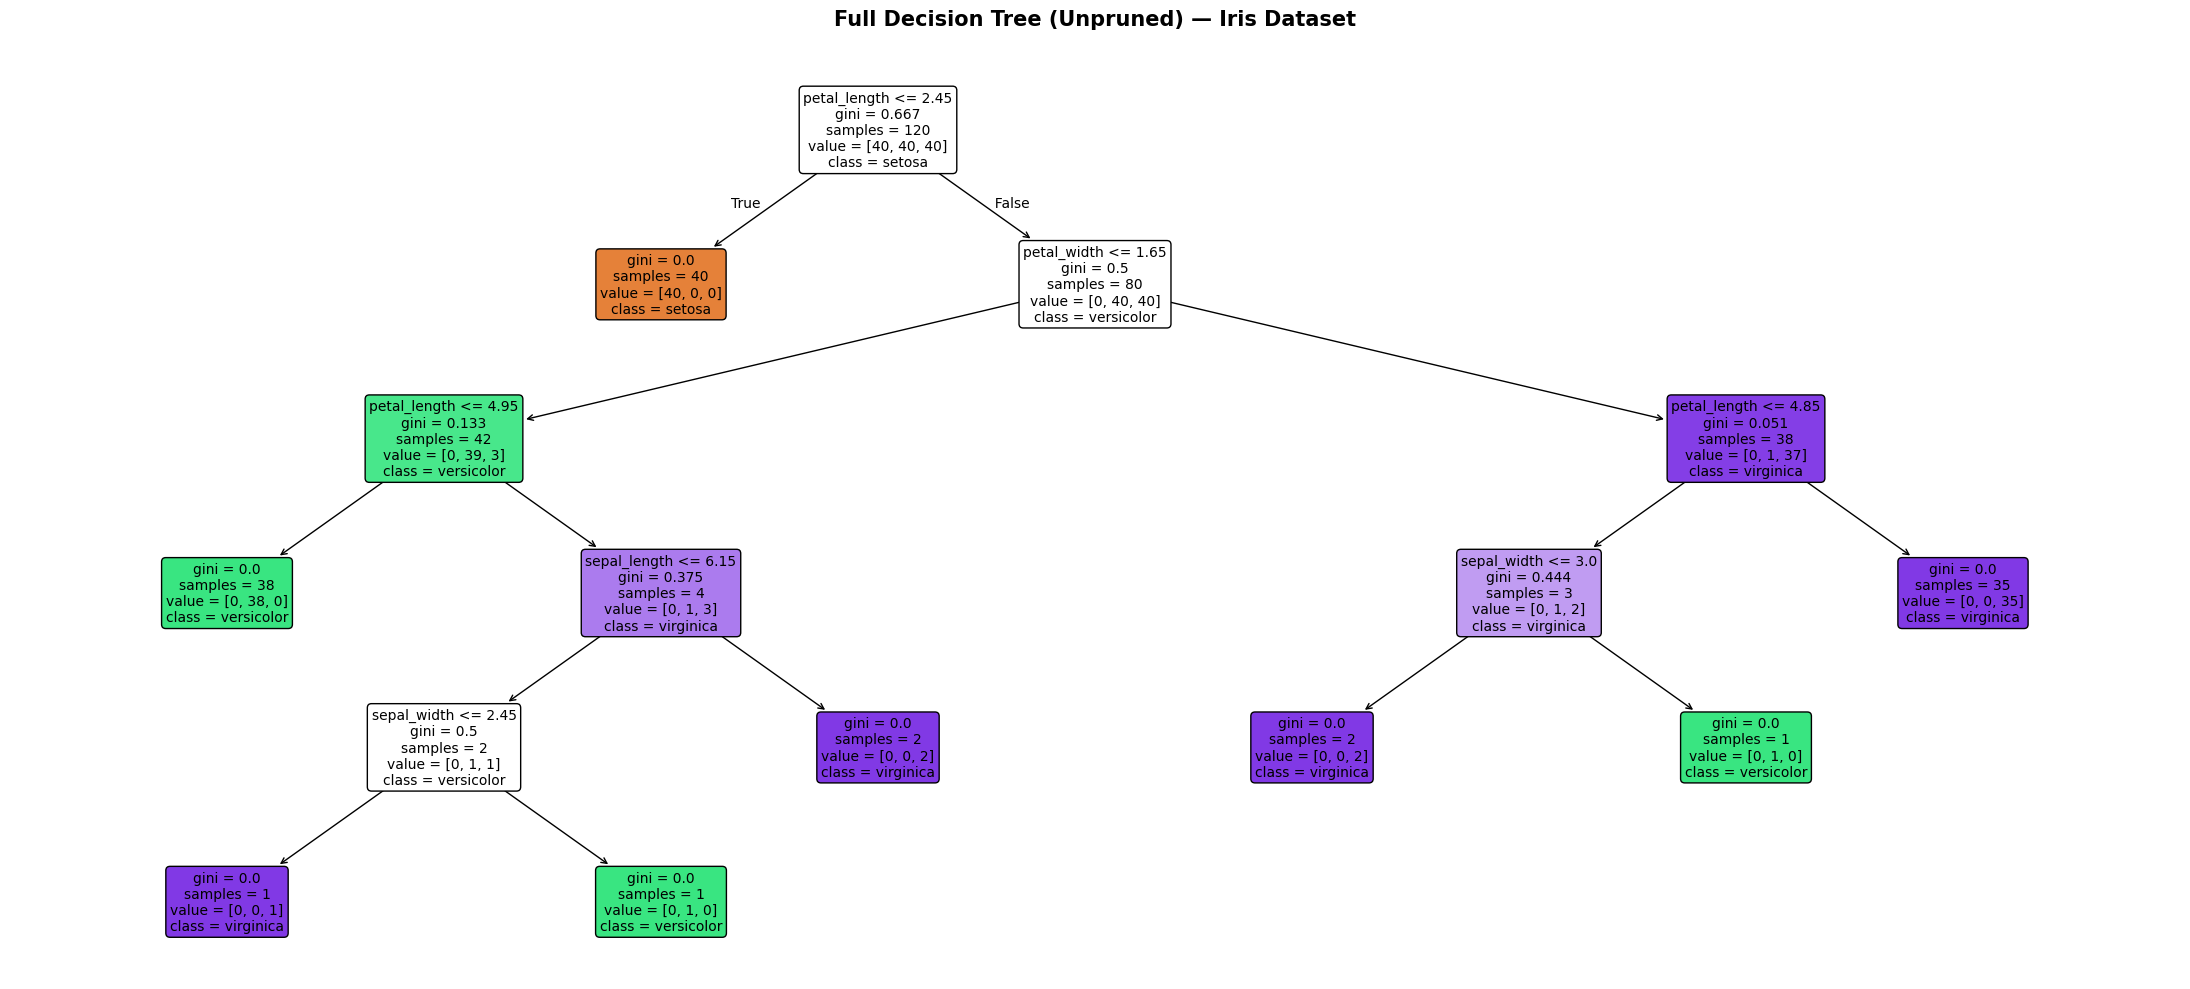

✅ Full tree plot saved!

📌 How to Read the Tree:
   Each node shows:
   • Splitting feature & threshold
   • Gini impurity (0 = pure, closer to 0 = better)
   • Samples at that node
   • Value = [class counts]
   • Class = predicted class at that node
   Darker color = higher class purity



In [4]:
# ============================================================
# STEP 4: Visualize the Full Tree Structure
# ============================================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    dt_full,
    feature_names=feature_cols,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True
)
plt.title('Full Decision Tree (Unpruned) — Iris Dataset',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full tree plot saved!")

print(f"""
📌 How to Read the Tree:
   Each node shows:
   • Splitting feature & threshold
   • Gini impurity (0 = pure, closer to 0 = better)
   • Samples at that node
   • Value = [class counts]
   • Class = predicted class at that node
   Darker color = higher class purity
""")

In [5]:
# ============================================================
# STEP 5: Prune the Tree — Find Best Max Depth
# ============================================================

depths      = range(1, 11)
acc_train_list = []
acc_test_list  = []
f1_test_list   = []

print(f"{'Depth':>6} | {'Train Acc':>10} | {'Test Acc':>9} | {'F1-Score':>9} | {'Leaves':>7}")
print("-" * 55)

for d in depths:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc  = accuracy_score(y_test,  dt.predict(X_test))
    test_f1   = f1_score(y_test, dt.predict(X_test), average='weighted')

    acc_train_list.append(train_acc)
    acc_test_list.append(test_acc)
    f1_test_list.append(test_f1)

    print(f"{d:>6} | {train_acc*100:>9.2f}% | {test_acc*100:>8.2f}% | {test_f1*100:>8.2f}% | {dt.get_n_leaves():>7}")

best_depth = depths[np.argmax(acc_test_list)]
print(f"\n🏆 Best Max Depth = {best_depth}  →  Test Accuracy = {max(acc_test_list)*100:.2f}%")

 Depth |  Train Acc |  Test Acc |  F1-Score |  Leaves
-------------------------------------------------------
     1 |     66.67% |    66.67% |    55.56% |       2
     2 |     96.67% |    93.33% |    93.33% |       3
     3 |     98.33% |    96.67% |    96.66% |       5
     4 |     99.17% |    93.33% |    93.33% |       7
     5 |    100.00% |    93.33% |    93.33% |       8
     6 |    100.00% |    93.33% |    93.33% |       8
     7 |    100.00% |    93.33% |    93.33% |       8
     8 |    100.00% |    93.33% |    93.33% |       8
     9 |    100.00% |    93.33% |    93.33% |       8
    10 |    100.00% |    93.33% |    93.33% |       8

🏆 Best Max Depth = 3  →  Test Accuracy = 96.67%


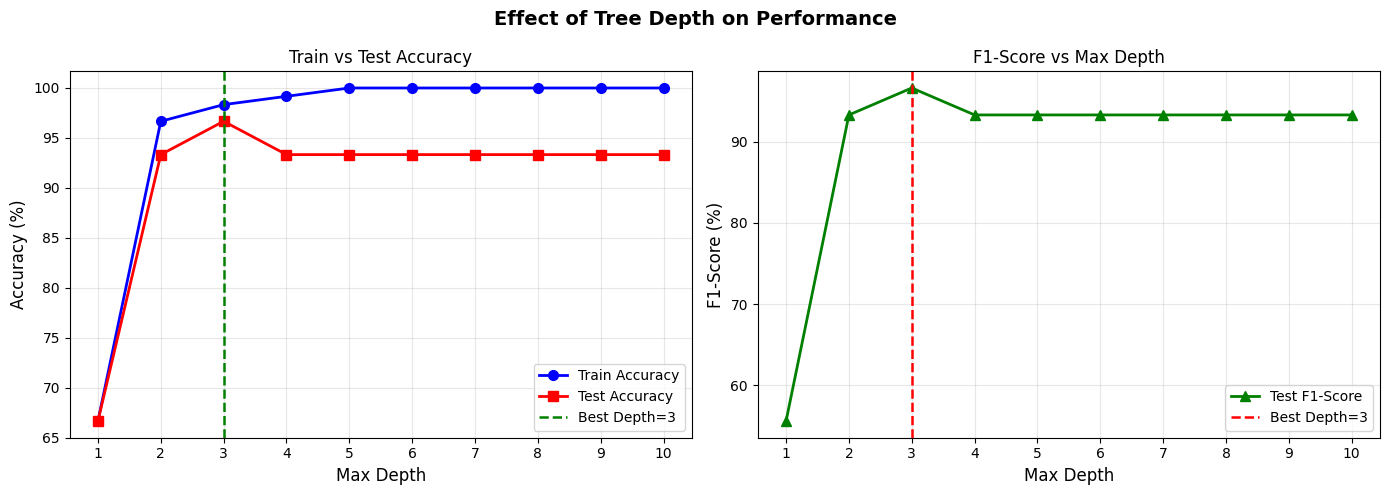

✅ Depth comparison plot saved!


In [6]:
# ============================================================
# STEP 6: Visualize Overfitting vs Pruning
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Tree Depth on Performance', fontsize=14, fontweight='bold')

# --- Plot 1: Train vs Test Accuracy ---
axes[0].plot(list(depths), [a*100 for a in acc_train_list],
             'bo-', linewidth=2, markersize=7, label='Train Accuracy')
axes[0].plot(list(depths), [a*100 for a in acc_test_list],
             'rs-', linewidth=2, markersize=7, label='Test Accuracy')
axes[0].axvline(x=best_depth, color='green', linestyle='--',
                linewidth=1.8, label=f'Best Depth={best_depth}')
axes[0].set_xlabel('Max Depth', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Train vs Test Accuracy', fontsize=12)
axes[0].set_xticks(list(depths))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: F1-Score vs Depth ---
axes[1].plot(list(depths), [f*100 for f in f1_test_list],
             'g^-', linewidth=2, markersize=7, label='Test F1-Score')
axes[1].axvline(x=best_depth, color='red', linestyle='--',
                linewidth=1.8, label=f'Best Depth={best_depth}')
axes[1].set_xlabel('Max Depth', fontsize=12)
axes[1].set_ylabel('F1-Score (%)', fontsize=12)
axes[1].set_title('F1-Score vs Max Depth', fontsize=12)
axes[1].set_xticks(list(depths))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('depth_comparison.png', dpi=150)
plt.show()
print("✅ Depth comparison plot saved!")

   PRUNED TREE (max_depth=3) — Evaluation
  Tree Depth    : 3
  Leaf Nodes    : 5
  Accuracy      : 96.67%
  F1-Score      : 96.66%

=== Classification Report (Pruned) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



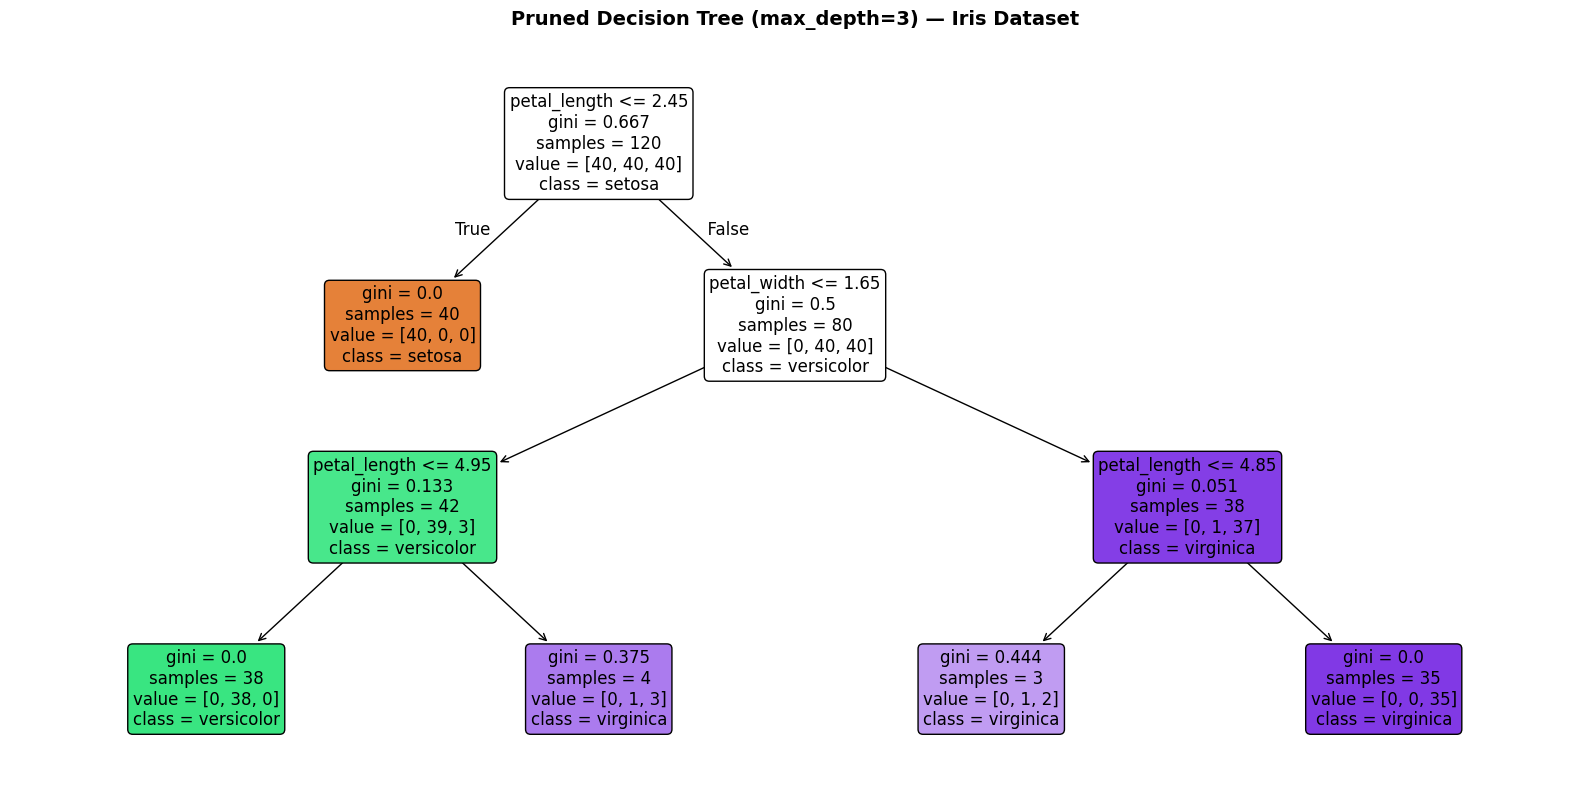

✅ Pruned tree plot saved!


In [7]:
# ============================================================
# STEP 7: Train & Visualize the Pruned Tree (Best Depth)
# ============================================================

dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=best_depth,
    min_samples_split=5,   # node must have ≥5 samples to split
    min_samples_leaf=2,    # leaf must have ≥2 samples
    random_state=42
)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)

acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned  = f1_score(y_test, y_pred_pruned, average='weighted')

print("=" * 50)
print(f"   PRUNED TREE (max_depth={best_depth}) — Evaluation")
print("=" * 50)
print(f"  Tree Depth    : {dt_pruned.get_depth()}")
print(f"  Leaf Nodes    : {dt_pruned.get_n_leaves()}")
print(f"  Accuracy      : {acc_pruned*100:.2f}%")
print(f"  F1-Score      : {f1_pruned*100:.2f}%")
print("=" * 50)
print("\n=== Classification Report (Pruned) ===")
print(classification_report(y_test, y_pred_pruned, target_names=le.classes_))

# --- Visualize pruned tree ---
plt.figure(figsize=(16, 8))
plot_tree(
    dt_pruned,
    feature_names=feature_cols,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=12,
    impurity=True
)
plt.title(f'Pruned Decision Tree (max_depth={best_depth}) — Iris Dataset',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree_pruned.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pruned tree plot saved!")

=== Feature Importances ===
     Feature  Importance
sepal_length    0.000000
 sepal_width    0.000000
 petal_width    0.420923
petal_length    0.579077


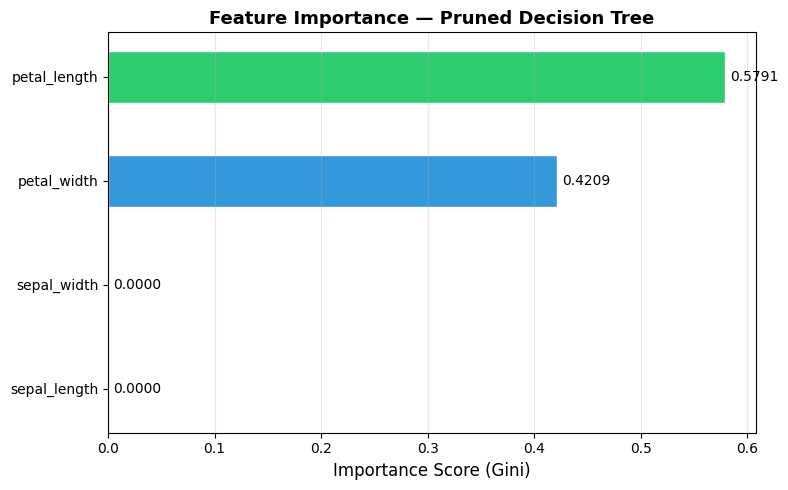

✅ Feature importance plot saved!


In [8]:
# ============================================================
# STEP 8: Feature Importance
# ============================================================

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': dt_pruned.feature_importances_
}).sort_values('Importance', ascending=True)

print("=== Feature Importances ===")
print(importance_df.to_string(index=False))

colors = ['#2ecc71' if i == importance_df['Importance'].max()
          else '#3498db' for i in importance_df['Importance']]

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors, edgecolor='white', height=0.5)
plt.xlabel('Importance Score (Gini)', fontsize=12)
plt.title('Feature Importance — Pruned Decision Tree',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
for i, (feat, imp) in enumerate(zip(importance_df['Feature'],
                                     importance_df['Importance'])):
    plt.text(imp + 0.005, i, f'{imp:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance plot saved!")

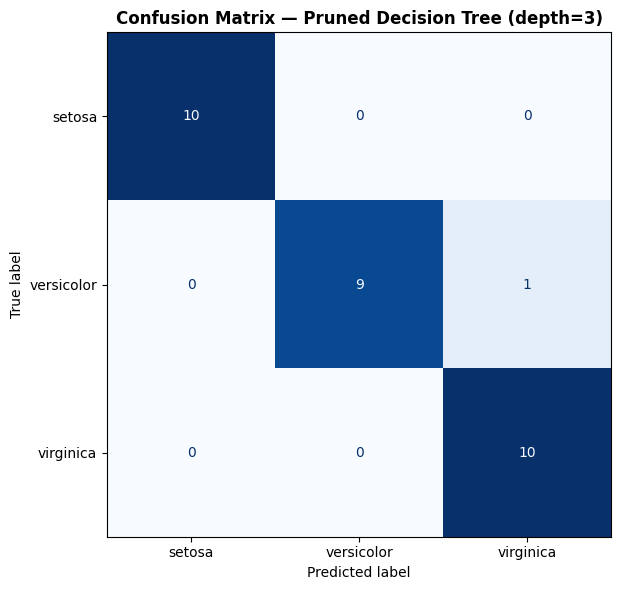

✅ Confusion matrix saved!


In [9]:
# ============================================================
# STEP 9: Confusion Matrix
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_pruned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Pruned Decision Tree (depth={best_depth})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [10]:
# ============================================================
# STEP 10: Final Comparison & Summary
# ============================================================

print("=" * 60)
print("       TASK 2 COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset       : Iris Flower Classification")
print(f"  Samples       : {len(df)}  |  Features: {len(feature_cols)}")
print(f"  Classes       : {list(le.classes_)}")
print(f"  Train/Test    : {len(X_train)} / {len(X_test)}")
print("-" * 60)
print(f"  {'Metric':<20} {'Full Tree':>12} {'Pruned Tree':>12}")
print(f"  {'-'*44}")
print(f"  {'Max Depth':<20} {dt_full.get_depth():>12} {dt_pruned.get_depth():>12}")
print(f"  {'Leaf Nodes':<20} {dt_full.get_n_leaves():>12} {dt_pruned.get_n_leaves():>12}")
print(f"  {'Accuracy':<20} {acc_full*100:>11.2f}% {acc_pruned*100:>11.2f}%")
print(f"  {'F1-Score':<20} {f1_full*100:>11.2f}% {f1_pruned*100:>11.2f}%")
print("=" * 60)

top_feat = importance_df.iloc[-1]
print(f"""
📌 Key Insights:
   • Most important feature : {top_feat['Feature']} ({top_feat['Importance']:.4f})
   • Pruning reduced leaves from {dt_full.get_n_leaves()} → {dt_pruned.get_n_leaves()}
   • Pruning prevents overfitting with little/no accuracy loss
   • Gini criterion measures node purity at each split
""")
print("✅ All plots saved. Model is ready!")

       TASK 2 COMPLETE — FINAL SUMMARY
  Dataset       : Iris Flower Classification
  Samples       : 150  |  Features: 4
  Classes       : ['setosa', 'versicolor', 'virginica']
  Train/Test    : 120 / 30
------------------------------------------------------------
  Metric                  Full Tree  Pruned Tree
  --------------------------------------------
  Max Depth                       5            3
  Leaf Nodes                      8            5
  Accuracy                   93.33%       96.67%
  F1-Score                   93.33%       96.66%

📌 Key Insights:
   • Most important feature : petal_length (0.5791)
   • Pruning reduced leaves from 8 → 5
   • Pruning prevents overfitting with little/no accuracy loss
   • Gini criterion measures node purity at each split

✅ All plots saved. Model is ready!
